# Imports

In [1]:
import os, gc, csv, time, json, pickle
import numpy as np
import pandas as pd
from datetime import datetime

from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

import torch
from sklearn.metrics.pairwise import cosine_similarity

from paths import text_emb_path, text_eval_dir

/home/aysel/tfe/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [2]:

CURRENT_DATASET = "Flickr8k"
BASE_DIR = "TFE_Data"

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print("Using device:", device)

TOP_KS = [1, 5, 10, 50]
TEXT_MODELS = ["BERT", "RoBERTa", "GPT2"]


Using device: cuda


# Utility Function

In [6]:
def ts():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")

def normalize_matrix(matrix):
    norms = np.linalg.norm(matrix, axis=1, keepdims=True)
    return matrix / np.where(norms == 0, 1e-9, norms)


# Performance

In [7]:
def recall_at_k_grouped(sim_matrix, k, group_size=5):
    N = sim_matrix.shape[0]
    ranks = np.argsort(-sim_matrix, axis=1)

    hits = []
    for i in range(N):
        group_id = i // group_size
        valid = list(range(group_id * group_size, (group_id + 1) * group_size))
        top_k = ranks[i, :k]
        hit = any(t in valid for t in top_k)
        hits.append(hit)

    return np.mean(hits)

In [10]:
results = []

for model in TEXT_MODELS:
    emb_path = text_emb_path(CURRENT_DATASET, model)

    if not os.path.exists(emb_path):
        print(f"[WARNING] Missing embeddings for {model}, skipping.")
        continue

    print(f"\n=== MODEL: {model} ===")

    X = np.load(emb_path)
    X_norm = normalize_matrix(X)
    sim = cosine_similarity(X_norm)

    res = {
        "dataset": CURRENT_DATASET,
        "model": model,
        "dim": X.shape[1],
    }

    for k in TOP_KS:
        res[f"recall@{k}"] = recall_at_k_grouped(sim, k, group_size=5)

    results.append(res)

df = pd.DataFrame(results)


out_path = text_eval_dir(CURRENT_DATASET, "text_retrieval_results.csv")
os.makedirs(os.path.dirname(out_path), exist_ok=True)
df.to_csv(out_path, index=False)
df.to_csv(out_path, index=False)

print("Saved to:", out_path)


=== MODEL: BERT ===

=== MODEL: RoBERTa ===

=== MODEL: GPT2 ===
Saved to: TFE_Data/Evaluations/Unimodal/text/Flickr8k/text_retrieval_results.csv


In [4]:
out_path = text_eval_dir(CURRENT_DATASET, "text_retrieval_results.csv")

df = pd.read_csv(out_path)
df

,dataset,model,dim,recall@1,recall@5,recall@10,recall@50
0,Flickr8k,BERT,768,0.993252,0.999802,1.0,1.0
1,Flickr8k,RoBERTa,768,0.993944,0.999852,1.0,1.0
2,Flickr8k,GPT2,768,0.993944,0.999852,1.0,1.0


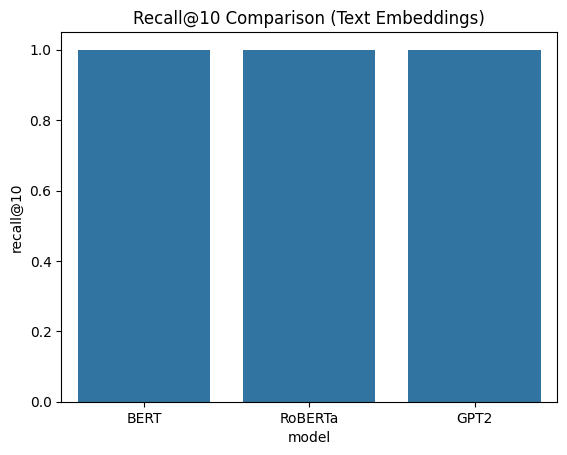

In [11]:
df = pd.read_csv(out_path)

sns.barplot(data=df, x="model", y="recall@10")
plt.title("Recall@10 Comparison (Text Embeddings)")
plt.show()


In [19]:
eff_df = pd.read_pickle(
    "TFE_Data/Embeddings/global_unimodal_metrics.pkl"
)

eff_text = eff_df.rename(columns={
    "Time_s": "embedding_time",
    "Latency_s": "inference_time",
    "Memory_MB": "memory_mb"
})

out_path = text_eval_dir(CURRENT_DATASET, "text_efficiency_results.csv")
os.makedirs(os.path.dirname(out_path), exist_ok=True)
eff_text.to_csv(out_path, index=False)

eff_text


,Dataset,Modality,Model,Num_Samples,embedding_time,inference_time,Throughput_samples_per_s,memory_mb
0,Flickr8k,vision,ResNet50,8091,18.159502,0.002244,445.551871,3624.875000
1,Flickr8k,vision,MobileNetV3,8091,12.114647,0.001497,667.869225,8.515625
2,Flickr8k,vision,ViT,8091,60.184088,0.007438,134.437529,5844.355469
3,Flickr8k,vision,PVT,8091,19.957821,0.002467,405.404981,6.582031
4,Flickr8k,text,BERT,40455,142.056809,0.003511,284.780437,9643.156250
5,Flickr8k,text,RoBERTa,40455,117.967974,0.002916,342.932058,4320.144531
6,Flickr8k,text,GPT2,40455,137.787950,0.003406,293.603323,3639.523438
